# Page to Pixel—Digitization, OCR, and Making Texts into Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UW-Madison-Digital-Scholarship-Hub/page-to-pixel/blob/main/Page-to-Pixel.ipynb)

In this notebook, we'll explore some of the different ways that the characters and words in digitized images of texts can be converted into digital formats. We'll work with one of the most commonly used Optical Character Recognition (OCR) engines, Tesseract, in its Python wrapper, `pytesseract`. We'll also test out some of the most recent Vision Language Models (VLMs), which adapt the technology of Large Language Models (LLMs) to interpret and then generate text. In the cells at the end of this notebook, you can upload your own images and test out the ability of the different models to correctly extract the text. 

> **Important Step**

Before running anything: switch to a GPU runtime. We're using some AI models in this notebook and running them "locally" (which is to say that we're running them in the notebook itself). In order to do this, we're going to need GPUs or Graphical Processing Units instead of the standard CPUs or Central Processing Units. 

By default, Colab starts you on a CPU-only runtime, so switch it manually:

1. Click **Runtime** in the menu bar at the top of the page.
2. Select **Change runtime type**.
3. Under **Hardware accelerator**, choose **T4 GPU**.
4. Click **Save**.

Colab will restart your session (this is normal). Once it's back, run the cells from the top.

In [13]:
""" If your're working in Colab, you can execute this cell to bring everything, 
including the sample data, over from the GitHub repository so that you can have 
it all in one place"""
!git clone https://github.com/UW-Madison-Digital-Scholarship-Hub/page-to-pixel.git
%cd page-to-pixel

Cloning into 'page-to-pixel'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 39 (delta 7), reused 35 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 23.98 MiB | 37.66 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/Users/bkrien/Workspace/text2data_workshops/page-to-pixel/page-to-pixel


In [14]:
# Packages to install if necessary
!apt-get install -y tesseract-ocr # Tesseract's underlying engine (pytesseract is just a Python wrapper around this)
!pip install pytesseract # main OCR package
!pip install Pillow #Python Image Library is the main image package
!pip install pandas # needed for pytesseract's DATAFRAME output
!pip install -q -U transformers accelerate torchvision # ML and VLM facilitation packages (-U for newer architectures like PaddleOCR-VL and Qwen3.5; torchvision is needed by the image/video processors)
!pip uninstall -y -q torchaudio # unused in this notebook, and its preinstalled build can end up compiled against a different CUDA version than the torch/torchvision we just upgraded, which breaks transformers imports


zsh:1: command not found: apt-get


In [15]:
# Packages to import
import pytesseract # Classic OCR package in Python
import torch # PyTorch is a deep learning framework
from PIL import Image # Python image processing library
from pytesseract import Output # import Output module for reporting data
import pandas as pd # pandas is useful for representing and manipulating data
import numpy as np # used for the binarization section below
from transformers import AutoProcessor, AutoModelForImageTextToText
from IPython.display import Markdown, display # lets us render GLM-OCR's Markdown output nicely

## Tesseract OCR Library

### Dickens

We have a page from Charles Dickens' *A Tale of Two Cities* from the HathiTrust Digital Library. This image has a single column of printed text, which makes it a good candidate for basic OCR processing. The original image can be access here: [https://babel.hathitrust.org/cgi/pt?id=hvd.32044024216053&seq=21](https://babel.hathitrust.org/cgi/pt?id=hvd.32044024216053&seq=21)

In [16]:
%%time
# Let's see what the text it outputs looks like
dickens = Image.open('sample_data/dickens.jpg') # Open the image
print(pytesseract.image_to_string(dickens)) # Process the image and output the text

A TALE OF TWO CITIES.
IN THREE BOOKS.

BY

CHARLES DICKENS.
VOL. L

ET

BOOK THE FIRST.

RECALLED TO LIFE.

CHAPTER I.
The Period.

Iv was the best of times, it was the worst of times,
it was the age of wisdom, it was the age of foolishness,
it was the epoch of belief, it was the epoch of incre-
dulity, it was the season of Light, it was the season
of Darkness, it was the spring of hope, it was the win-
ter of despair, we had everything before us, we had
nothing before us, we were all going direct to Heaven,
we were all going direct the other way — in short, the
period was so far like the present period, that some of
its noisiest authorities insisted on its being received,
_for good or for evil, in the superlative degree of com-
parison only. * 1%

Google

CPU times: user 15.8 ms, sys: 13.1 ms, total: 28.8 ms
Wall time: 515 ms


### Getting confidence scores

`image_to_string` only returns plain text. To get Tesseract's per-word confidence (0-100, or -1 for non-text regions like lines), use `image_to_data`, which also gives bounding boxes for each recognized word.

In [17]:
dickens_data = pytesseract.image_to_data(dickens, output_type=Output.DATAFRAME) # Let's take a look at the data 

# Drop rows with no recognized text (conf == -1) and preview word-level confidence
dickens_words = dickens_data[dickens_data.conf != -1][['text', 'conf', 'left', 'top', 'width', 'height']]
dickens_words.head(20)

,text,conf,left,top,width,height
4,A,96.774300,477,729,65,69
5,TALE,95.865318,598,726,260,74
6,OF,96.161652,917,723,129,77
7,TWO,95.899612,1101,724,229,77
8,CITIES.,96.249382,1386,722,332,78
10,IN,96.246429,815,877,65,42
11,THREE,96.422119,917,876,204,42
12,BOOKS.,96.494560,1154,875,213,43
16,BY,96.655952,1058,1013,72,36
20,CHARLES,95.875282,722,1095,354,57


In [18]:
# A single overall confidence score for the page
print(f"Average word confidence for the dickens text: {dickens_words.conf.mean():.1f}")

Average word confidence for the dickens text: 93.5


### The Gettysburg Address

Our next image is significantly more complicated. It's a handwritten draft of Lincoln's "Gettysburg Address." Handwriting, even relatively neat and legible handwriting, is much less consistent that printed text. This image is from the Library of Congress and can be accessed at: [https://www.loc.gov/resource/mal.4356600/?st=text&r=-0.066,-0.288,1.111,1.432,0](https://www.loc.gov/resource/mal.4356600/?st=text&r=-0.066,-0.288,1.111,1.432,0)

In [19]:
%%time
# Again, we'll start with the text output
gettysburg = Image.open('sample_data/gettysburg.jpg') # Open the image
print(pytesseract.image_to_string(gettysburg)) # Process the image and output the text

ruv ecme anev seven yeors age Cry forbes
bange frk, pow KA Coutenend, a henwr ration, Cont
Cewees tw VberS” an clecteelcn 6 Be frgftentins
VOTE OLE! Piven, Gags Cie CeO agrck,

Now pres Be Prgepeed pe yore Cink way Ge:
“ey whether LKaD ator oy Ang Malach, bo Conceunal,
Prov fo clectes€ev Con beg preter, Ne aw Mer
PS re a ped batho feted fe ie

meds: eee Clecthitvets a polos Ge ad ite fica

Prev fvcfier AAEO bres pho Cs ale ee,

Pe ew ae Farge br 20 We Caw [rut clectesta—
We Cen (hoC Coiecie Wwe Caw hod halen ges
Y acenanie tke Qs Trew fatting
poor
, mia dics as Cokzgen geo tO fe aleve cu, ower
be acto or eCOrzee, DE wWorkev nr £6 Le, i
(ov fog pemmeintey t\hal Gr Hay. Keres Via i

vey


CPU times: user 16.4 ms, sys: 18.7 ms, total: 35.1 ms
Wall time: 762 ms


In [20]:
# Let's take a look at the data and, in particular, the confidence:
gettysburg_data = pytesseract.image_to_data(gettysburg, output_type=Output.DATAFRAME) # Let's take a look at the data 

# Drop rows with no recognized text (conf == -1) and preview word-level confidence
gettysburg_words = gettysburg_data[gettysburg_data.conf != -1][['text', 'conf', 'left', 'top', 'width', 'height']]
gettysburg_words.head(20)

,text,conf,left,top,width,height
4,ruv,0.000000,1461,249,94,52
5,ecme,0.000000,1583,245,105,84
6,anev,58.477577,1716,245,91,84
7,seven,0.484810,1835,245,119,84
8,yeors,35.119865,1982,245,126,84
9,age,69.577896,2125,266,83,62
10,Cry,61.301174,2225,256,65,65
11,forbes,43.025341,2311,256,126,65
13,bange,0.000000,1420,339,143,70
14,"frk,",67.052475,1572,349,114,55


In [21]:
# A single overall confidence score for the page
print(f"Average word confidence for the gettysburg text: {gettysburg_words.conf.mean():.1f}")

Average word confidence for the gettysburg text: 33.5


### Preprocessing: Does Binarization Help?

When working with Tesseract or other, similar tools, explicitly *binarizing* first — converting the image to pure black-and-white — can sometimes help it more than its own defaults do. We'll compute the threshold automatically with [Otsu's method](https://en.wikipedia.org/wiki/Otsu%27s_method), which picks the pixel value that best separates the image into two classes (foreground vs. background) by maximizing the variance between them. We'll then re-run Tesseract on the result.

Otsu threshold: 131


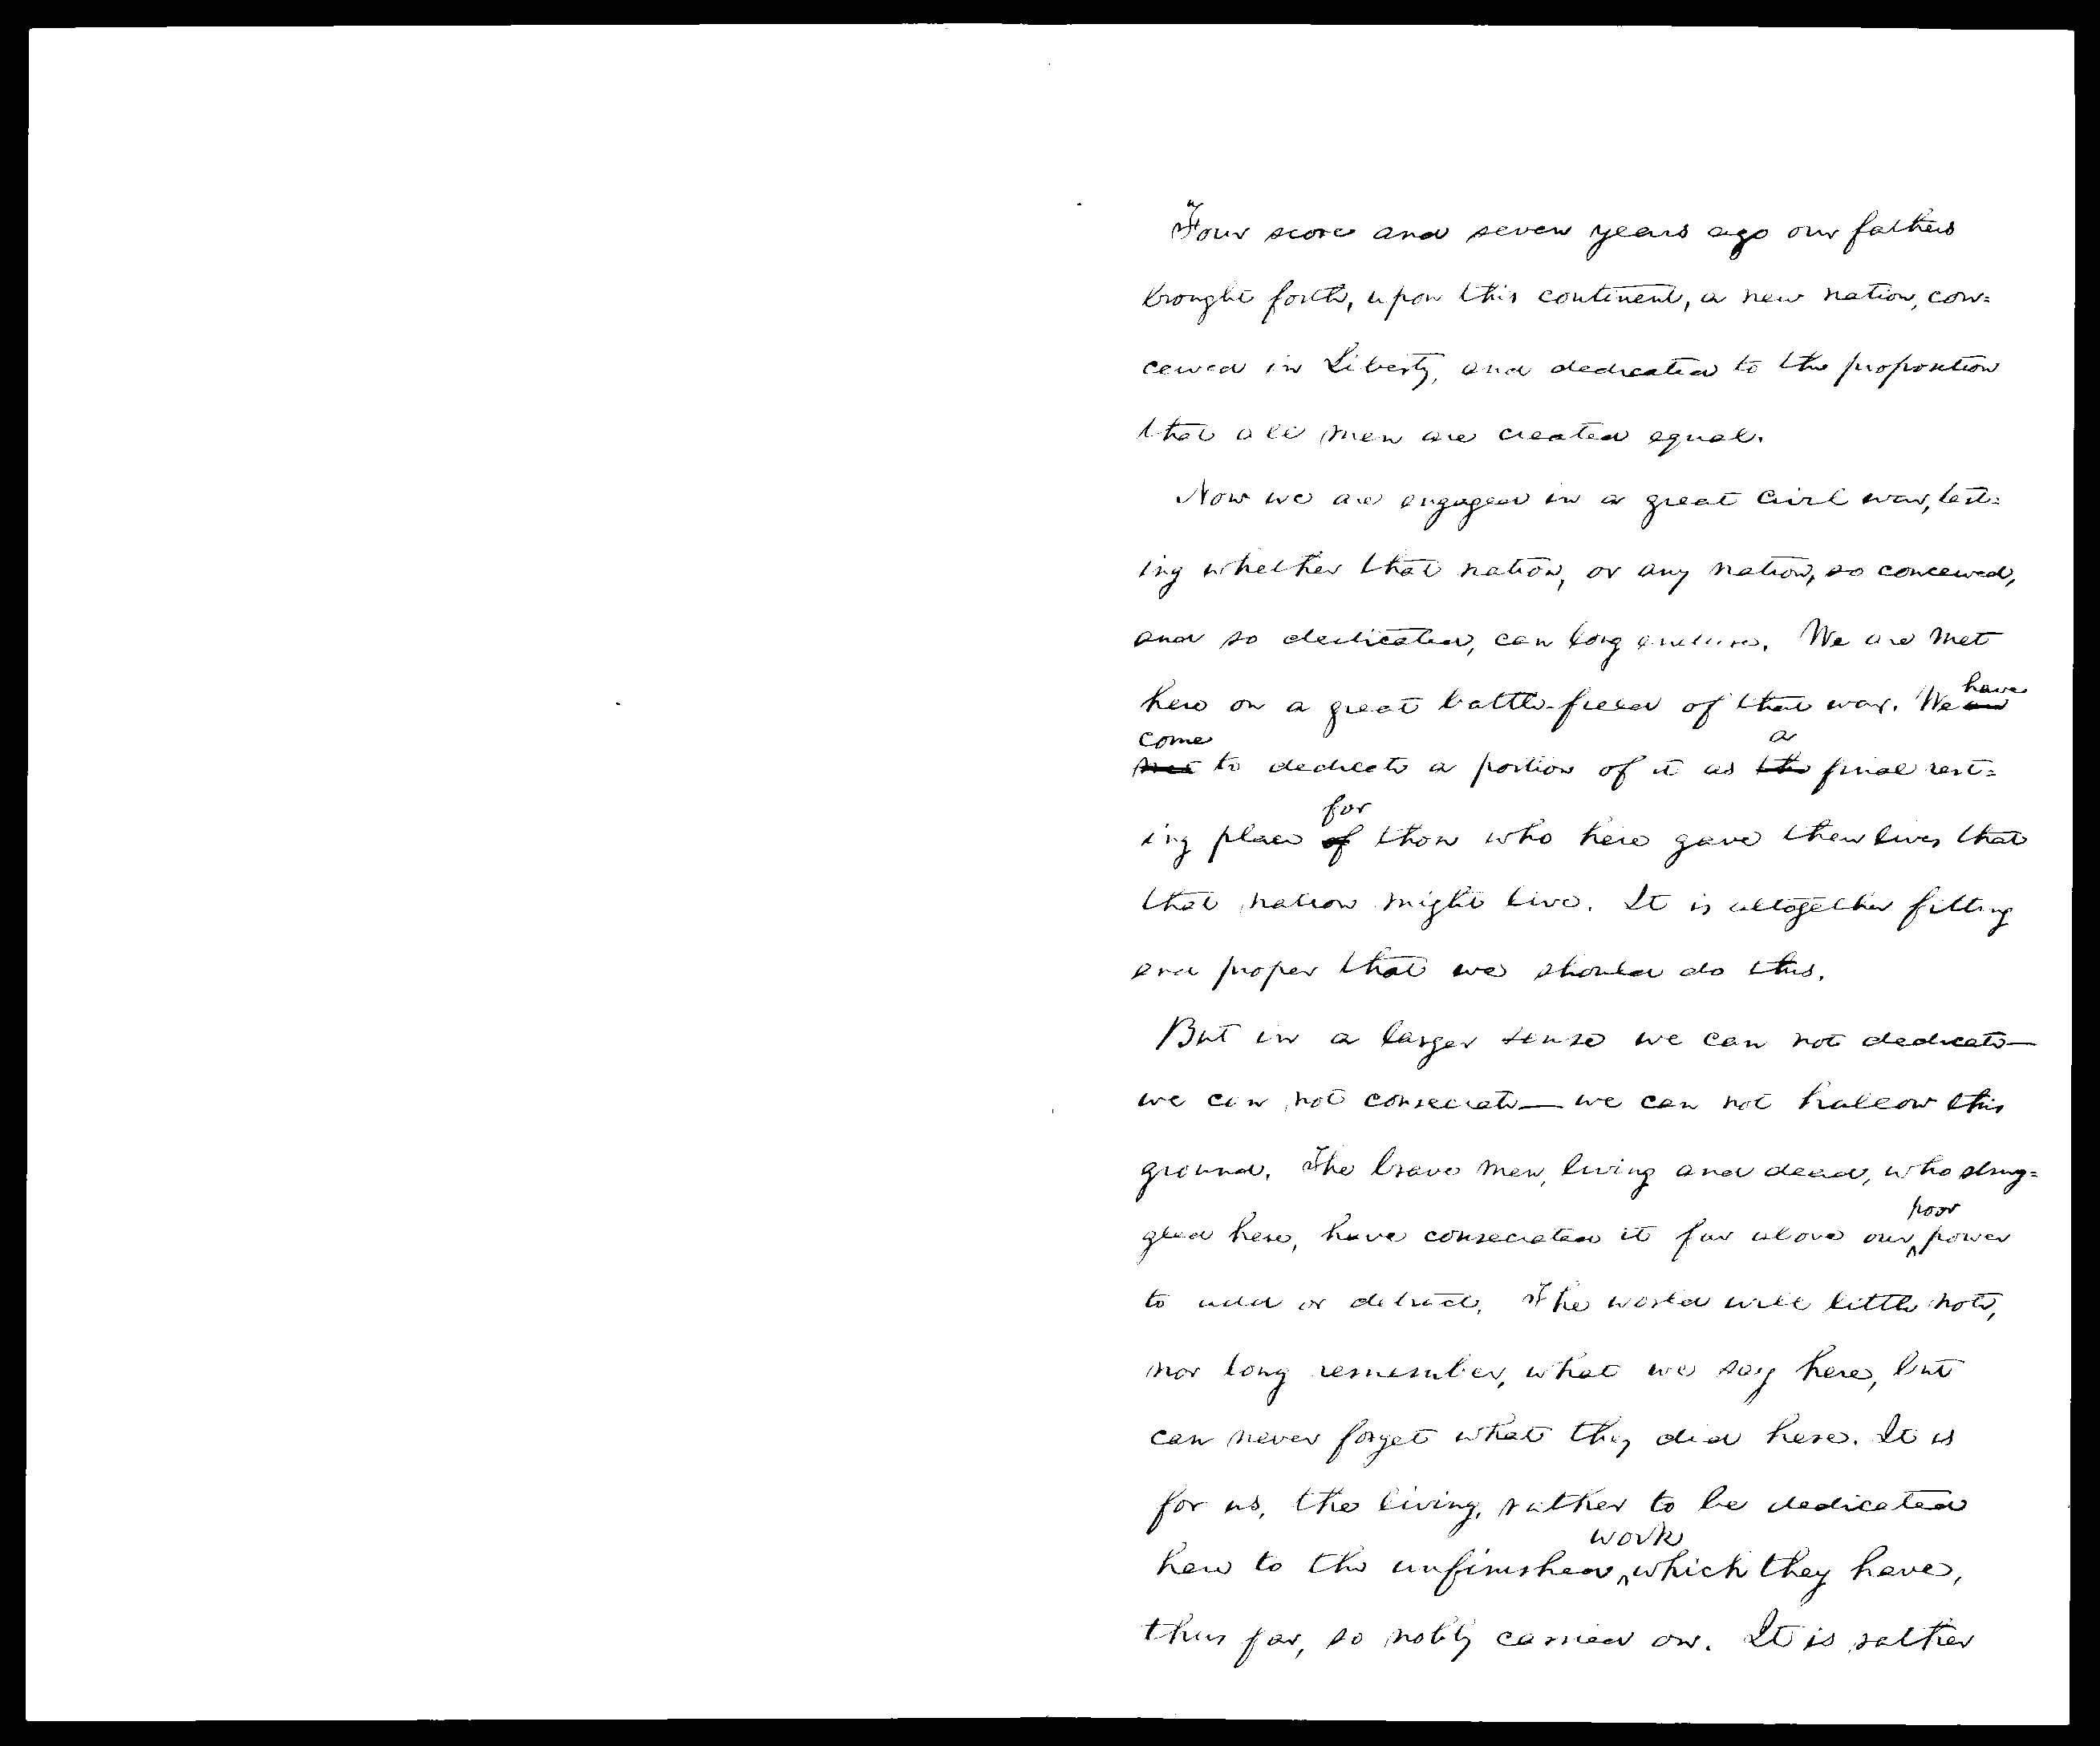

In [22]:
def otsu_threshold(image):
    """Find the pixel value that best splits the image's brightness
    histogram into two classes (e.g. ink vs. paper)."""
    gray = np.array(image.convert('L'))
    histogram, _ = np.histogram(gray.flatten(), bins=256, range=(0, 256))
    total = gray.size
    sum_all = np.dot(np.arange(256), histogram)

    best_threshold, best_variance = 0, 0
    sum_below, weight_below = 0, 0
    for t in range(256):
        weight_below += histogram[t]
        if weight_below == 0:
            continue
        weight_above = total - weight_below
        if weight_above == 0:
            break
        sum_below += t * histogram[t]
        mean_below = sum_below / weight_below
        mean_above = (sum_all - sum_below) / weight_above
        between_class_variance = weight_below * weight_above * (mean_below - mean_above) ** 2
        if between_class_variance > best_variance:
            best_variance = between_class_variance
            best_threshold = t
    return best_threshold

threshold = otsu_threshold(gettysburg)
gettysburg_binarized = gettysburg.convert('L').point(lambda p: 255 if p > threshold else 0)
print(f"Otsu threshold: {threshold}")
gettysburg_binarized

In [23]:
%%time
print(pytesseract.image_to_string(gettysburg_binarized))

yey EEOP ED Apne Ere rows Jy 2 z
op on fF

rong he fo®, bfrow Ch Coutinert, aw hes Nel eo:
Ceiwwrte fw Li bad Cie htealipeteu) CE Be fog Laer aeligrt
Mkeb O CL Pirew Gres Keen tow Sg nety

ew Wwe au ew eed bw & ‘eel Grrl wn Bids

TF y ’
Lig het fas LKEE Pebhond ov any Vial PO Cone
Prov go elerteglial Con bons Git ler ees, We rw Wet
d a

Come ,
(Pom La ole ettle £5 a fertors fe ad btw Ltrak) tare

ber vr
Alea bw a& berger LERAO We Can het cleetreaio—
bre Cow he Cobice wh — We Can he hetenr CF,
pore the breve Vrscrd Leviug Are Here, ashe eng:
poor
were Kese, Ka rer COkpet.g Ga tO aw ttigue tay fretived
& cwetet wey 2G Crees ok fio Werte techie, LATE, Ag
ev feng letneintiey wheel we voy Keres Lowe”

Wwovks


CPU times: user 23.2 ms, sys: 10.5 ms, total: 33.6 ms
Wall time: 578 ms


In [24]:
# Compare against the raw (non-binarized) average confidence from above
binarized_data = pytesseract.image_to_data(gettysburg_binarized, output_type=Output.DATAFRAME)
binarized_words = binarized_data[binarized_data.conf != -1][['text', 'conf', 'left', 'top', 'width', 'height']]
print(f"Average word confidence, raw:       {gettysburg_words.conf.mean():.1f}")
print(f"Average word confidence, binarized: {binarized_words.conf.mean():.1f}")

Average word confidence, raw:       33.5
Average word confidence, binarized: 34.5


## Vision Language Models

While Vision Language Models (VLMs) perform a similar task to traditional Optical Character Recognition tools like Tesseract, they go about it in a very different way. They are partly interpretive but also partly generative, which means that, when applied to a text they can't correctly process, they are much less likely to output meaningless strings of characters but much more likely to output coherent but incorrect information. 

In [ ]:
# Both VLMs below will use whatever accelerator is available
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() # Use Apple Silicon if working on a Mac
    else "cpu" # Use the CPU if neither GPU nor MPS is available
)

# T4 GPUs (Colab's free tier) are Turing-generation and lack hardware-accelerated
# bfloat16, so float16 runs faster there; Ampere+ GPUs and Apple Silicon (MPS)
# handle bfloat16 natively.
if device == "cuda":
    model_dtype = "bfloat16" if torch.cuda.get_device_capability()[0] >= 8 else "float16"
elif device == "mps":
    model_dtype = "bfloat16"
else:
    model_dtype = "float32"

print(f"Using device: {device} ({model_dtype})")
if device == "cpu":
    print("No GPU detected. In Colab, go to Runtime → Change runtime type → T4 GPU," \
    " then rerun this cell. The VLM cells below will be very slow on CPU. " \
    "Ask Brady if you need help")

# The VLMs eat up a lot of memory so decreasing the resolution of the images helps. 
def resize_for_vlm(image, max_dimension=1024):
    """Downscale so the vision encoder doesn't tokenize the full-resolution
    image into an unmanageable number of patches. VLMs process images
    at close to their native resolution, so a large scan or phone photo can
    otherwise trigger a CUDA out-of-memory error during generation."""
    width, height = image.size
    if max(width, height) <= max_dimension:
        return image
    scale = max_dimension / max(width, height)
    return image.resize((round(width * scale), round(height * scale)))

gettysburg_for_vlm = resize_for_vlm(gettysburg)

Using device: mps (bfloat16)


### General Vision Language Model 

[Qwen3.5](https://huggingface.co/Qwen/Qwen3.5-0.8B) is an open-weight model created by the Chinese company, Alibaba. It's trained on interleaved text, image, and video bit it's a general-purpose chat model, not an OCR specialist, so we prompt it conversationally and give it our handwritten Gettysburg Address image.

In [26]:
%%time
# Note: this first run also includes downloading and loading the model,
# so it's not a pure inference-speed measurement — re-run the cell to see
# how fast generation alone is once the model is already in memory.
qwen_processor = AutoProcessor.from_pretrained("Qwen/Qwen3.5-0.8B")
qwen_model = AutoModelForImageTextToText.from_pretrained(
    "Qwen/Qwen3.5-0.8B",
    dtype=model_dtype,
    attn_implementation="sdpa", # avoids the eager attention fallback, which is far more memory-hungry
).to(device)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": gettysburg_for_vlm},
            {"type": "text", "text": "Transcribe all of the text in this image."},
        ],
    }
]

qwen_inputs = qwen_processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(qwen_model.device)

qwen_outputs = qwen_model.generate(**qwen_inputs, max_new_tokens=512)
qwen_result = qwen_processor.decode(
    qwen_outputs[0][qwen_inputs["input_ids"].shape[-1]:],
    skip_special_tokens=True,
)
print(qwen_result)

Loading weights: 100%|██████████| 473/473 [00:00<00:00, 8458.85it/s]


Your verse are seven years ago on faiths
brought forth, upon this continent, a new nation can
serve in liberty, and dedicated to the preference
that all men are created equal.
Now we are engaged in a great and endless
by what fear that nation, or my methods, so conceivably,
and so electorates, can long endure. We are that
have a great battle field of their war. We have
come to dedicate a portion of it as the finest parts
for big play of them who have given them that they might live. It is allegorical filling
our promise that we shall do this.
But in a larger sense we can not electors
we can not connect—we can not believe this
generous. The have men being one dear who sing
how, have connected it to few alone enough
to win a desire. It the note will little not,
for long remember what we pay here, but
can never forget that they dear here. It is
for us, the living rather to be dedicated
NOW
how to the unfinishing, which they have,
thus far, so very common now. It is seton

CPU times: user 

### OCR Vision Language Model

[GLM-OCR](https://huggingface.co/zai-org/GLM-OCR) is a compact (0.9B parameter) document-parsing VLM from Zhipu AI (Z.ai), currently ranked #1 on the OmniDocBench V1.5 leaderboard. Like PaddleOCR-VL, it's a specialist rather than a general chat model, but it's driven the same way we prompted Qwen3.5 above — through a chat template — with a short task instruction such as `"OCR:"`.

In [27]:
%%time
# Note: this first run also includes downloading and loading the model,
# so it's not a pure inference-speed measurement — re-run the cell to see
# how fast generation alone is once the model is already in memory.
glm_processor = AutoProcessor.from_pretrained("zai-org/GLM-OCR")
glm_model = AutoModelForImageTextToText.from_pretrained(
    "zai-org/GLM-OCR",
    dtype=model_dtype,
    attn_implementation="sdpa", # avoids the eager attention fallback, which is far more memory-hungry
).to(device)

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": gettysburg_for_vlm},
            {"type": "text", "text": "OCR:"},
        ],
    }
]

glm_inputs = glm_processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
).to(glm_model.device)
glm_inputs.pop("token_type_ids", None)  # GLM-OCR's processor adds this, but generate() doesn't accept it

glm_outputs = glm_model.generate(**glm_inputs, max_new_tokens=512)
glm_result = glm_processor.decode(
    glm_outputs[0][glm_inputs["input_ids"].shape[-1]:],
    skip_special_tokens=True,
)

# GLM-OCR is trained to emit layout-aware Markdown (headers, lists, tables) for structured pages,
# so we render it as Markdown instead of plain text, and save it to preserve the formatting
display(Markdown(glm_result))
with open('glm_result.md', 'w') as f:
    f.write(glm_result)

Loading weights: 100%|██████████| 510/510 [00:00<00:00, 9475.50it/s]


Your score and seven years ago our feathers
brought forth, upon this continent, a new nation, con-
served in liberty, and dedicated to the propitious
that all men are created equal.

Now we are engaged in a great contest now late,
try whether that nation, or any nation, so conceived,
and so dedicated, can long endure. We are met
here or a great battlefield of those wars. We have
come to decide a portion of it as the final rests
of those who here gave their lives, that
that nation might live. It is altogether fitting
proper that we please do this.

But in a larger sense we can not decide
we can not conceive we can not hear this
ground, the brave men living and dead, who slung
gloves here, have conceived it for alms our power
to aid or defend, the world will little not,
not long remember what we pay here, but
can never forget what they do here. It is
for us, the living, rather to be decimated
how to this unfinished, which they have,
thus far, so nobly carried on. It is rather

CPU times: user 1.37 s, sys: 1.61 s, total: 2.98 s
Wall time: 9.62 s


## Try Your Own Image

Feel free to test everything above on an image of your own — a photo of a book page, a handwritten note, anything with text in it. Run the cell below to upload a file from your computer.

A couple of things to keep in mind:
- The upload only lasts for this Colab session — it isn't saved anywhere once you disconnect.
- This is a shared classroom machine, so avoid uploading anything sensitive or personal.

In [28]:
from google.colab import files

uploaded = files.upload()
my_image_path = list(uploaded.keys())[0]
my_image = Image.open(my_image_path)
my_image_for_vlm = resize_for_vlm(my_image) # phone photos in particular can be huge — see the note above
my_image # Displays the image inline so you can confirm the right file loaded

ModuleNotFoundError: No module named 'google'

### Tesseract

In [ ]:
print(pytesseract.image_to_string(my_image))

### Vision Language Models

The `qwen_model` and `glm_model` from above are still loaded in memory, so trying them on your image doesn't require re-downloading anything — just build a new prompt with your image. Here's GLM-OCR again, this time on your upload:

In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": my_image_for_vlm},
            {"type": "text", "text": "OCR:"},
        ],
    }
]

my_inputs = glm_processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
).to(glm_model.device)
my_inputs.pop("token_type_ids", None)

my_outputs = glm_model.generate(**my_inputs, max_new_tokens=512)
my_result = glm_processor.decode(
    my_outputs[0][my_inputs["input_ids"].shape[-1]:],
    skip_special_tokens=True,
)
display(Markdown(my_result))

Want to try Qwen3.5 instead? Copy the cell above, swap `glm_processor`/`glm_model` for `qwen_processor`/`qwen_model`, and change the prompt to something like `"Transcribe all of the text in this image."`